# Cas de Tests PMC

In [308]:
import ctypes
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [309]:
#lib = ctypes.CDLL("./cmake-build-debug/libProjet_Annuel_3IABD.dll")
lib = ctypes.CDLL("./cmake-build-debug/libProjet_Annuel_3IABD.so")

c_int = ctypes.c_int
c_double = ctypes.c_double
c_void_p = ctypes.c_void_p

c_double_p = ctypes.POINTER(c_double)
c_double_p_p = ctypes.POINTER(c_double_p)
c_int_p = ctypes.POINTER(c_int)

lib.init_pmc.argtypes = [c_int_p, c_int, c_double]
lib.init_pmc.restype = c_void_p

lib.train.argtypes = [c_void_p, c_double_p, c_double_p, c_int, c_int, c_int]
lib.train.restype = c_double

lib.propagation.argtypes = [c_void_p, c_double_p_p, c_int, c_double_p_p]
lib.propagation.restype = None

lib.predict.argtypes = [c_void_p, c_double_p, c_int, c_int, c_int]
lib.predict.restype = c_double_p

lib.free_p.argtypes = [c_double_p]
lib.free_p.restype = None

lib.free_pmc.argtypes = [c_void_p]
lib.free_pmc.restype = None

## Classification

### Cas 1 - Lineaire Simple

#### Input et etat initial

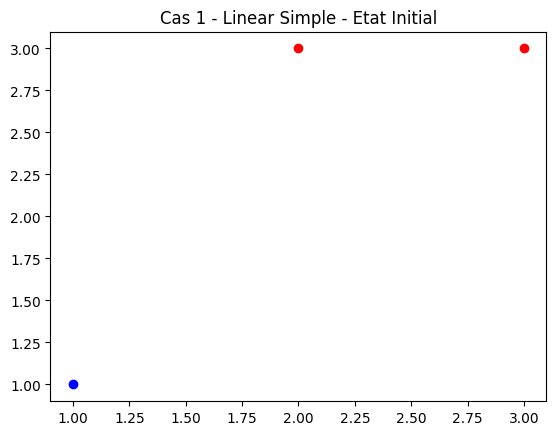

<Figure size 640x480 with 0 Axes>

In [310]:
X = np.array([
    [1, 1],
    [2, 3],
    [3, 3]
], dtype=np.float64)

Y = np.array([
    1,
    -1,
    -1
], dtype=np.float64)

plt.scatter(X[0, 0], X[0, 1], color='blue')
plt.scatter(X[1:3,0], X[1:3,1], color='red')
plt.title("Cas 1 - Linear Simple - Etat Initial")
plt.show()
plt.clf()


#### Initialisation et entrainement du Model

In [311]:
layers = (c_int * 2)(2, 1)

nb_layers     = 2
learning_rate = 0.5

model = lib.init_pmc(layers, nb_layers, learning_rate)

nb_sample          = 3
nb_data_per_sample = 2

input = (c_double * (nb_sample * nb_data_per_sample))(
    *X.flatten()
)

y_true = (c_double * nb_sample)(
    *Y
)

epochs = 100
losses = []

for epoch in range(epochs):
    loss = lib.train(model, input, y_true, nb_sample, nb_data_per_sample, 1)
    losses.append(loss)

pred_ptr = lib.predict(model, input, nb_sample, nb_data_per_sample, 1)
preds = np.array([pred_ptr[i] for i in range(nb_sample)])
pred_labels = np.where(preds >= 0, 1, -1)

#### Etat de sortie

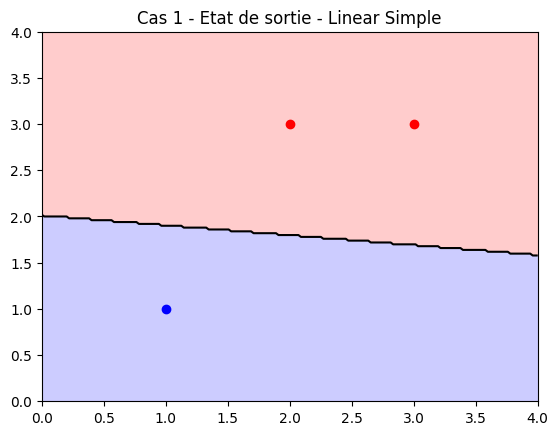

<Figure size 640x480 with 0 Axes>

In [312]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]
nb_grid     = grid_points.shape[0]

grid_input = (c_double * (nb_grid * nb_data_per_sample))(
    *grid_points.flatten()
)

grid_pred_ptr = lib.predict(model, grid_input, nb_grid, nb_data_per_sample, 1)
grid_preds    = np.array([grid_pred_ptr[i] for i in range(nb_grid)])
grid_labels   = np.where(grid_preds >= 0, 1, -1).reshape(xx.shape)

lib.free_p(grid_pred_ptr)

plt.contourf(xx, yy, grid_labels, alpha=0.2, levels=[-2, 0, 2], colors=['red', 'blue'])
plt.contour(xx, yy, grid_labels, levels=[0], colors='black', linewidths=1.5)
plt.scatter(X[0, 0], X[0, 1], color='blue', zorder=5)
plt.scatter(X[1:3, 0], X[1:3, 1], color='red', zorder=5)
plt.title("Cas 1 - Etat de sortie - Linear Simple")
plt.show()
plt.clf()

#### Courbe de Loss

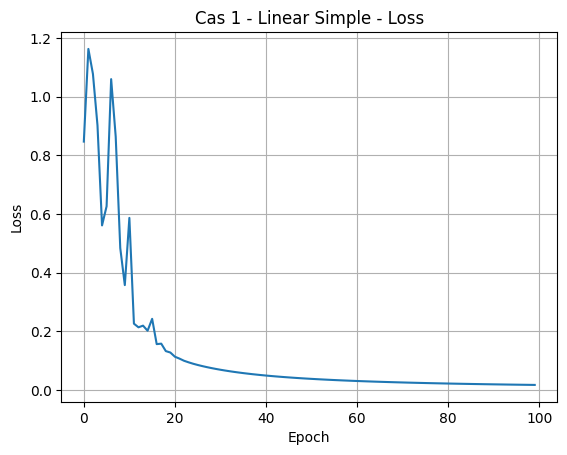

In [313]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Cas 1 - Linear Simple - Loss")
plt.grid()
plt.show()

lib.free_p(pred_ptr)
lib.free_pmc(model)


### Cas 2 - Lineaire Multiple

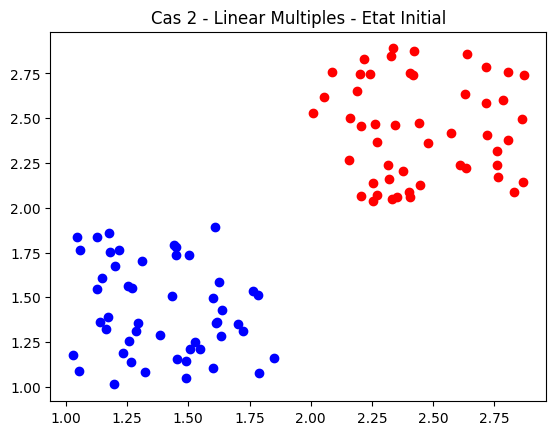

<Figure size 640x480 with 0 Axes>

In [314]:
X = np.concatenate([np.random.random((50,2)) * 0.9 + np.array([1, 1]), np.random.random((50,2)) * 0.9 + np.array([2, 2])])
Y = np.concatenate([np.ones((50, 1)), np.ones((50, 1)) * -1.0])

plt.title("Cas 2 - Linear Multiples - Etat Initial")
plt.scatter(X[0:50, 0], X[0:50, 1], color='blue')
plt.scatter(X[50:100,0], X[50:100,1], color='red')
plt.show()
plt.clf()


In [315]:
layers = (c_int * 2)(2, 1)

nb_layers     = 2
learning_rate = 0.3

model = lib.init_pmc(layers, nb_layers, learning_rate)

nb_sample = X.shape[0]
nb_data_per_sample = X.shape[1]

input = (c_double * (nb_sample * nb_data_per_sample))(
    *X.flatten()
)

y_true = (c_double * nb_sample)(
    *Y.flatten()
)

pochs = 100
losses = []

for epoch in range(epochs):
    loss = lib.train(model, input, y_true, nb_sample, nb_data_per_sample, 1)
    losses.append(loss)

pred_ptr = lib.predict(model, input, nb_sample, nb_data_per_sample, 1)
preds = np.array([pred_ptr[i] for i in range(nb_sample)])
pred_labels = np.where(preds >= 0, 1, -1)

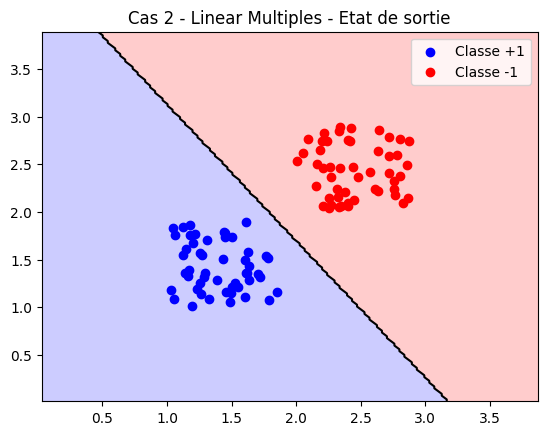

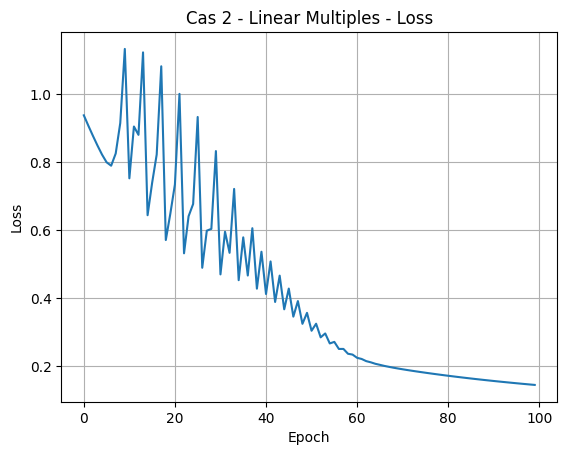

In [316]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]
nb_grid = grid_points.shape[0]

grid_input = (c_double * (nb_grid * nb_data_per_sample))(
    *grid_points.flatten()
)

grid_pred_ptr = lib.predict(model, grid_input, nb_grid, nb_data_per_sample, 1)
grid_preds = np.array([grid_pred_ptr[i] for i in range(nb_grid)])
grid_labels = np.where(grid_preds >= 0, 1, -1).reshape(xx.shape)

lib.free_p(grid_pred_ptr)

plt.contourf(xx, yy, grid_labels, alpha=0.2, levels=[-2, 0, 2], colors=['red', 'blue'])
plt.contour(xx, yy, grid_labels, levels=[0], colors='black', linewidths=1.5)

plt.scatter(X[0:50, 0], X[0:50, 1], color='blue', zorder=5, label='Classe +1')
plt.scatter(X[50:100, 0], X[50:100, 1], color='red', zorder=5, label='Classe -1')

plt.title("Cas 2 - Linear Multiples - Etat de sortie")
plt.legend()
plt.show()
plt.clf()

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Cas 2 - Linear Multiples - Loss")
plt.grid()
plt.show()

lib.free_p(pred_ptr)
lib.free_pmc(model)

### Cas 3 - XOR

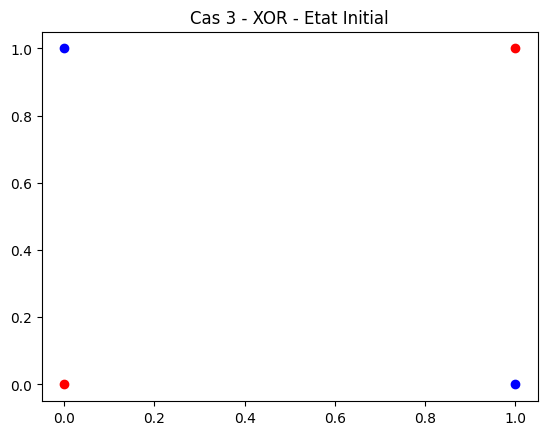

<Figure size 640x480 with 0 Axes>

In [317]:
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]])
Y = np.array([1, 1, -1, -1])

plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4,0], X[2:4,1], color='red')
plt.title("Cas 3 - XOR - Etat Initial")
plt.show()
plt.clf()

In [318]:
layers = (c_int * 3)(2, 2, 1)

nb_layers     = 3
learning_rate = 0.5

model = lib.init_pmc(layers, nb_layers, learning_rate)

nb_sample = X.shape[0]
nb_data_per_sample = X.shape[1]

input = (c_double * (nb_sample * nb_data_per_sample))(
    *X.flatten()
)

y_true = (c_double * nb_sample)(
    *Y.flatten()
)

epochs = 2000
losses = []

for epoch in range(epochs):
    loss = lib.train(model, input, y_true, nb_sample, nb_data_per_sample, 1)
    losses.append(loss)

pred_ptr = lib.predict(model, input, nb_sample, nb_data_per_sample, 1)
preds = np.array([pred_ptr[i] for i in range(nb_sample)])
pred_labels = np.where(preds >= 0, 1, -1)

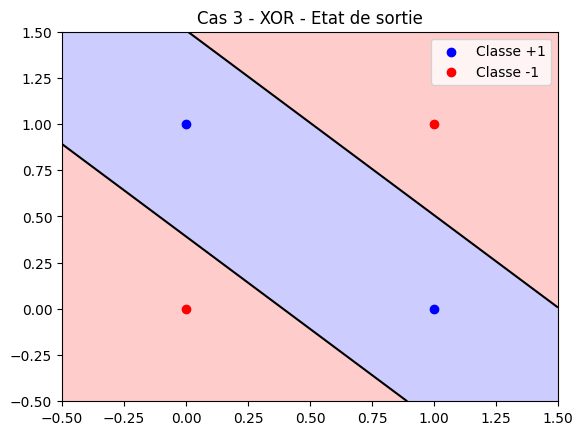

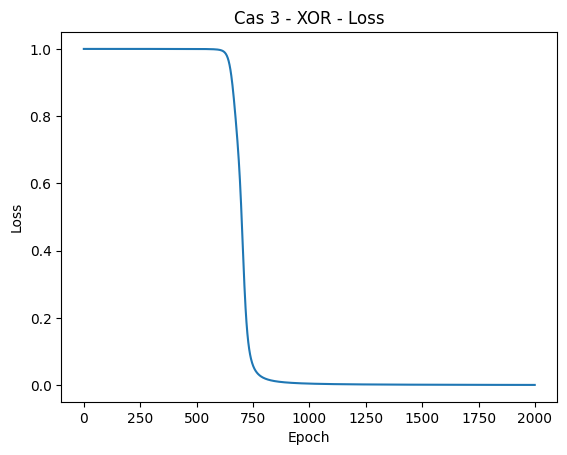

In [319]:
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]
nb_grid = grid_points.shape[0]

grid_input = (c_double * (nb_grid * nb_data_per_sample))(
    *grid_points.flatten()
)

grid_pred_ptr = lib.predict(model, grid_input, nb_grid, nb_data_per_sample, 1)
grid_preds = np.array([grid_pred_ptr[i] for i in range(nb_grid)])
grid_labels = np.where(grid_preds >= 0, 1, -1).reshape(xx.shape)

lib.free_p(grid_pred_ptr)

plt.contourf(xx, yy, grid_labels, alpha=0.2, levels=[-2, 0, 2], colors=['red', 'blue'])
plt.contour(xx, yy, grid_labels, levels=[0], colors='black', linewidths=1.5)

plt.scatter(X[0:2, 0], X[0:2, 1], color='blue', zorder=5, label='Classe +1')
plt.scatter(X[2:4, 0], X[2:4, 1], color='red', zorder=5, label='Classe -1')

plt.title("Cas 3 - XOR - Etat de sortie")
plt.legend()
plt.show()
plt.clf()

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Cas 3 - XOR - Loss")
plt.show()

lib.free_p(pred_ptr)
lib.free_pmc(model)

### Cas 4 - Cross

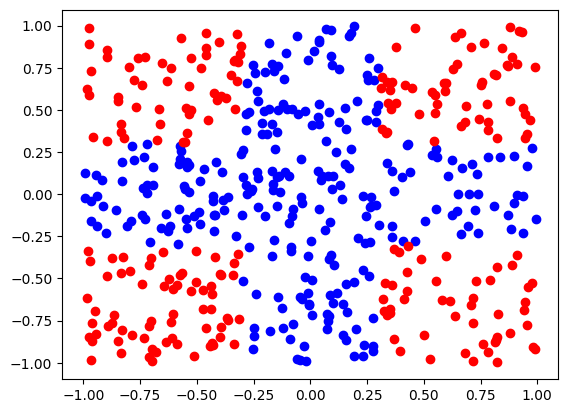

<Figure size 640x480 with 0 Axes>

In [320]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X])

plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,1], color='red')
plt.show()
plt.clf()

In [321]:
layers = (c_int * 3)(2, 4, 1)

nb_layers     = 3
learning_rate = 0.5

model = lib.init_pmc(layers, nb_layers, learning_rate)

nb_sample = X.shape[0]
nb_data_per_sample = X.shape[1]

input = (c_double * (nb_sample * nb_data_per_sample))(
    *X.flatten()
)

y_true = (c_double * nb_sample)(
    *Y.flatten()
)

epochs = 10000
losses = []

for epoch in range(epochs):
    loss = lib.train(model, input, y_true, nb_sample, nb_data_per_sample, 1)
    losses.append(loss)

pred_ptr = lib.predict(model, input, nb_sample, nb_data_per_sample, 1)
preds = np.array([pred_ptr[i] for i in range(nb_sample)])
pred_labels = np.where(preds >= 0, 1, -1)

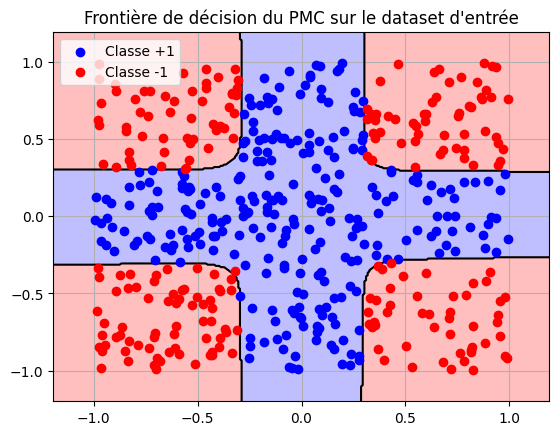

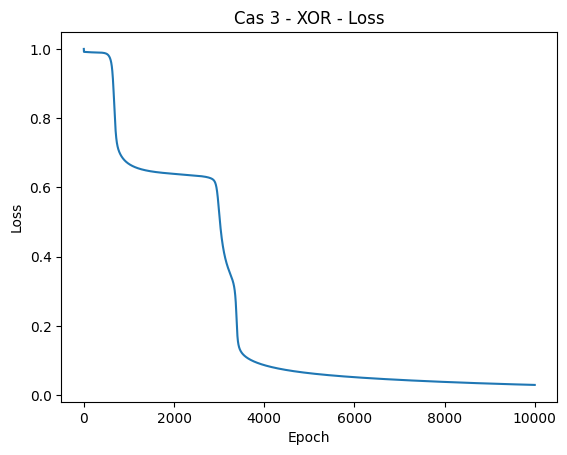

In [ ]:
x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]
nb_grid = grid_points.shape[0]

grid_input = (c_double * (nb_grid * nb_data_per_sample))(
    *grid_points.flatten()
)

grid_pred_ptr = lib.predict(model, grid_input, nb_grid, nb_data_per_sample, 1)
grid_preds = np.array([grid_pred_ptr[i] for i in range(nb_grid)])

grid_labels = np.where(grid_preds >= 0, 1, -1).reshape(xx.shape)

lib.free_p(grid_pred_ptr)

plt.title("Cas 4 - Cross - Etat de sortie")

plt.contourf(xx, yy, grid_labels, alpha=0.25, levels=[-2, 0, 2], colors=['red', 'blue'])
plt.contour(xx, yy, grid_labels, levels=[0], colors='black', linewidths=1.5)

X_pos = np.array(list(map(lambda elt: elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))
X_neg = np.array(list(map(lambda elt: elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))

plt.scatter(X_pos[:, 0], X_pos[:, 1], color='blue', label='Classe +1', zorder=5)
plt.scatter(X_neg[:, 0], X_neg[:, 1], color='red', label='Classe -1', zorder=5)

plt.legend()
plt.grid()
plt.show()
plt.clf()

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Cas 3 - XOR - Loss")
plt.show()

lib.free_p(pred_ptr)
lib.free_pmc(model)

### Cas 5 - Multi Linear 3 Class

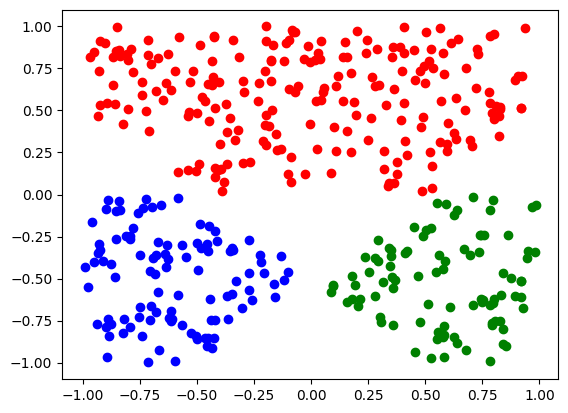

<Figure size 640x480 with 0 Axes>

In [323]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, 1, -1] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, -1, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [-1, -1, -1]for p in X])

X = X[[not np.all(arr == [-1, -1, -1]) for arr in Y]]
Y = Y[[not np.all(arr == [-1, -1, -1]) for arr in Y]]

plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

In [324]:
layers = (c_int * 2)(2, 1)

nb_layers     = 2
learning_rate = 0.5

model = lib.init_pmc(layers, nb_layers, learning_rate)

nb_sample = X.shape[0]
nb_data_per_sample = X.shape[1]

input = (c_double * (nb_sample * nb_data_per_sample))(
    *X.flatten()
)

y_true = (c_double * nb_sample)(
    *Y.flatten()
)

pochs = 100
losses = []

for epoch in range(epochs):
    loss = lib.train(model, input, y_true, nb_sample, nb_data_per_sample, 1)
    losses.append(loss)

pred_ptr = lib.predict(model, input, nb_sample, nb_data_per_sample, 1)
preds = np.array([pred_ptr[i] for i in range(nb_sample)])
pred_labels = np.where(preds >= 0, 1, -1)

IndexError: invalid index

### Cas 6 - Multi Cross

In [ ]:
X = np.random.random((1000, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else [-1, 1, -1] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else [-1, -1, 1] for p in X])

plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

In [ ]:
layers = (c_int * 2)(2, 1)

nb_layers     = 2
learning_rate = 0.5

model = lib.init_pmc(layers, nb_layers, learning_rate)

nb_sample = X.shape[0]
nb_data_per_sample = X.shape[1]

input = (c_double * (nb_sample * nb_data_per_sample))(
    *X.flatten()
)

y_true = (c_double * nb_sample)(
    *Y.flatten()
)

pochs = 100
losses = []

for epoch in range(epochs):
    loss = lib.train(model, input, y_true, nb_sample, nb_data_per_sample, 1)
    losses.append(loss)

pred_ptr = lib.predict(model, input, nb_sample, nb_data_per_sample, 1)
preds = np.array([pred_ptr[i] for i in range(nb_sample)])
pred_labels = np.where(preds >= 0, 1, -1)

## Regression

### Cas 7 - Linear Simple 2d

In [ ]:
X = np.array([
      [1],
      [2]
])
Y = np.array([
      2,
      3
])

plt.scatter(X,Y)
plt.show()
plt.clf()

### Cas 8 - Non Linear Simple 2d

In [ ]:
X = np.array([
      [1],
      [2],
      [3]
])
Y = np.array([
      2,
      3,
      2.5
])

plt.scatter(X,Y)
plt.show()
plt.clf()

### Cas 9 - Linear Simple 3d

In [ ]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 1]
])
Y = np.array([
      2,
      3,
      2.5
])

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

### Cas 10 - Linear Tricky 3d

In [ ]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 3]
])
Y = np.array([
      1,
      2,
      3
])

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()



### Cas 11 - Non linear Simple 3d

In [ ]:
X = np.array([
      [1, 0],
      [0, 1],
      [1, 1],
      [0, 0],
])
Y = np.array([
      2,
      1,
      -2,
      -1
])

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

### Cas 12 - Part Data Set